# PNC Banking Project - Quick Setup Guide

## 📋 Pre-requisites Checklist

Before starting, ensure you have:
- [ ] Python 3.8 or higher installed
- [ ] PostgreSQL 12 or higher installed and running
- [ ] VS Code (or any code editor)
- [ ] Terminal/Command Prompt access

## 🚀 Step-by-Step Setup Instructions

### Step 1: Create Project Directory Structure

```bash
mkdir pnc_churn_analysis
cd pnc_churn_analysis

# Create subdirectories
mkdir sql
mkdir src
```

### Step 2: Create All Project Files

Copy the content from each artifact into the corresponding files:

1. **README.md** → Root directory
2. **.gitignore** → Root directory
3. **requirements.txt** → Root directory
4. **schema.sql** → `sql/` directory
5. **1_generate_data.py** → `src/` directory
6. **2_churn_analysis_and_modeling.ipynb** → `src/` directory

Your structure should look like:
```
pnc_churn_analysis/
├── .gitignore
├── README.md
├── requirements.txt
├── sql/
│   └── schema.sql
└── src/
    ├── 1_generate_data.py
    └── 2_churn_analysis_and_modeling.ipynb
```

### Step 3: Set Up Python Environment

```bash
# Create virtual environment
python -m venv .venv

# Activate it
# On Windows:
.venv\Scripts\activate

# On Mac/Linux:
source .venv/bin/activate

# Install dependencies
pip install -r requirements.txt
```

### Step 4: Set Up PostgreSQL Database

#### Option A: Using Command Line

```bash
# Create database
createdb pnc_banking

# Run schema
psql -d pnc_banking -f sql/schema.sql
```

#### Option B: Using pgAdmin or Another GUI

1. Open pgAdmin
2. Create a new database named `pnc_banking`
3. Open Query Tool
4. Copy content from `sql/schema.sql`
5. Execute the script

### Step 5: Update Database Credentials

Update the `DB_PARAMS` dictionary in **two files**:

**File 1:** `src/1_generate_data.py` (Line 22-27)
```python
DB_PARAMS = {
    'host': 'localhost',
    'database': 'pnc_banking',
    'user': 'YOUR_USERNAME',      # ← Change this
    'password': 'YOUR_PASSWORD'    # ← Change this
}
```

**File 2:** `src/2_churn_analysis_and_modeling.ipynb` (Cell 2)
```python
DB_PARAMS = {
    'host': 'localhost',
    'database': 'pnc_banking',
    'user': 'YOUR_USERNAME',      # ← Change this
    'password': 'YOUR_PASSWORD'    # ← Change this
}
```

### Step 6: Generate and Load Data

```bash
# Run the data generation script
python src/1_generate_data.py
```

**Expected Output:**
```
==============================================================
PNC BANKING DATA GENERATION
==============================================================

Created data/ directory
Generating 5000 customers...
✓ Generated 5000 customers
Generating accounts...
✓ Generated 8247 accounts
Generating loans...
✓ Generated 2003 loans
Generating churn data...
✓ Generated churn data for 5000 customers
  - Churned customers: 1234

Saving data to CSV files...
✓ Saved customers.csv
✓ Saved accounts.csv
✓ Saved loans.csv
✓ Saved churn.csv

==============================================================
DATA GENERATION COMPLETE!
==============================================================

==============================================================
LOADING DATA INTO POSTGRESQL DATABASE
==============================================================
Connecting to PostgreSQL database...
✓ Connected successfully
...
✓ Successfully loaded 5000 customers into database
✓ Successfully loaded 8247 accounts into database
✓ Successfully loaded 2003 loans into database
✓ Successfully loaded 5000 churn records into database

==============================================================
DATABASE LOADING COMPLETE!
==============================================================
```

### Step 7: Run Jupyter Notebook Analysis

```bash
# Start Jupyter
jupyter notebook

# OR if you prefer Jupyter Lab
jupyter lab
```

1. Navigate to `src/2_churn_analysis_and_modeling.ipynb`
2. Update database credentials in Cell 2 (if not done already)
3. Run all cells: `Cell → Run All`

### Step 8: Verify Everything Works

**Quick Database Check:**
```sql
-- Connect to database and run these queries
SELECT COUNT(*) FROM customers;  -- Should return 5000
SELECT COUNT(*) FROM accounts;   -- Should return ~8000+
SELECT COUNT(*) FROM loans;      -- Should return ~2000
SELECT COUNT(*) FROM churn;      -- Should return 5000
```

## 🔧 Troubleshooting

### Issue: "Connection refused" or "Authentication failed"

**Solution:**
1. Check PostgreSQL is running: `pg_isready`
2. Verify credentials are correct
3. Check PostgreSQL is accepting connections on localhost:5432

### Issue: "Module not found" errors

**Solution:**
```bash
# Make sure virtual environment is activated
pip install -r requirements.txt

# If still issues, try upgrading pip first
pip install --upgrade pip
```

### Issue: Data generation script fails

**Solution:**
1. Ensure the database exists: `psql -l | grep pnc_banking`
2. Ensure schema is created: Check tables exist
3. Check file permissions for creating `data/` directory

### Issue: Jupyter notebook can't find psycopg2

**Solution:**
```bash
# Install in the correct environment
pip install psycopg2-binary

# OR restart Jupyter kernel
```

## 📊 Next Steps After Setup

1. **Explore the Data:**
   - Review the generated CSV files in `data/` directory
   - Query the database directly to understand the data

2. **Analyze the Results:**
   - Review all visualizations in the notebook
   - Note the churn rate and default rate
   - Examine model performance metrics

3. **Create Tableau Dashboard:**
   - Export cleaned data from notebook if needed
   - Connect Tableau to PostgreSQL directly
   - Build visualizations based on the insights

4. **Customize the Project:**
   - Adjust the number of customers (change `NUM_CUSTOMERS`)
   - Modify churn/default probabilities in the generation script
   - Try different ML models (Random Forest, XGBoost)
   - Add more features to improve predictions

## 🎯 Project Deliverables Checklist

- [ ] Data generated and loaded into PostgreSQL
- [ ] Jupyter notebook executed successfully
- [ ] All visualizations displayed correctly
- [ ] Model trained with accuracy > 70%
- [ ] README.md updated with your findings
- [ ] Tableau dashboard created (optional but recommended)
- [ ] GitHub repository created with code
- [ ] Project added to portfolio/resume

## 💡 Tips for Portfolio Presentation

1. **Highlight Business Impact:**
   - "Identified 3 key churn drivers saving $X in retention costs"
   - "Built ML model with 85% accuracy for loan default prediction"

2. **Show Technical Skills:**
   - End-to-end pipeline (data generation → database → analysis → modeling)
   - SQL joins, Python, Machine Learning, Data Visualization
   - Database design with proper normalization

3. **Demonstrate Problem-Solving:**
   - How you handled data quality issues
   - Feature engineering decisions
   - Model selection rationale

## 📞 Need Help?

Common resources:
- PostgreSQL docs: https://www.postgresql.org/docs/
- Pandas docs: https://pandas.pydata.org/docs/
- Scikit-learn docs: https://scikit-learn.org/stable/
- Faker docs: https://faker.readthedocs.io/

---

**Good luck with your portfolio project! 🚀**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
import os
from dotenv import load_dotenv


warnings.filterwarnings('ignore')

In [9]:

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [11]:
# Database connection parameters (UPDATE WITH YOUR CREDENTIALS)
load_dotenv()

DB_PARAMS = {
    'host': os.getenv("host"),
    'database': os.getenv("database"),
    'user': os.getenv("user"),
    'password': os.getenv("password")
}

# Connect to PostgreSQL database
try:
    conn = psycopg2.connect(**DB_PARAMS)
    print("✓ Successfully connected to PostgreSQL database")
except Exception as e:
    print(f"❌ Connection error: {e}")

✓ Successfully connected to PostgreSQL database


In [12]:
# SQL query to join all tables
query = """
SELECT 
    c.customer_id,
    c.first_name,
    c.last_name,
    c.age,
    c.gender,
    c.city,
    c.join_date,
    a.account_id,
    a.account_type,
    a.balance,
    a.open_date,
    l.loan_id,
    l.loan_amount,
    l.interest_rate,
    l.loan_term_months,
    l.loan_status,
    ch.churn_status,
    ch.churn_date,
    CURRENT_DATE - c.join_date AS tenure_days
FROM customers c
LEFT JOIN accounts a ON c.customer_id = a.customer_id
LEFT JOIN loans l ON c.customer_id = l.customer_id
LEFT JOIN churn ch ON c.customer_id = ch.customer_id
ORDER BY c.customer_id;
"""

# Load data into pandas DataFrame
df = pd.read_sql_query(query, conn)

# Close database connection
conn.close()

print(f"✓ Data loaded successfully")
print(f"  - Total records: {len(df):,}")
print(f"  - Columns: {len(df.columns)}")

✓ Data loaded successfully
  - Total records: 8,232
  - Columns: 19


In [13]:
df.head()

,customer_id,first_name,last_name,age,gender,city,join_date,account_id,account_type,balance,open_date,loan_id,loan_amount,interest_rate,loan_term_months,loan_status,churn_status,churn_date,tenure_days
0,1,Danielle,Johnson,56,Female,Johnberg,2017-07-14,1,CD,178.69,2020-04-06,1318.0,69444.82,4.01,48.0,Defaulted,0,None,3019
1,1,Danielle,Johnson,56,Female,Johnberg,2017-07-14,2,CD,1217.28,2020-11-14,1318.0,69444.82,4.01,48.0,Defaulted,0,None,3019
2,2,Erica,Mcclain,32,Female,New Roberttown,2017-05-21,3,CD,47033.65,2025-08-02,NaN,NaN,NaN,NaN,None,0,None,3073
3,2,Erica,Mcclain,32,Female,New Roberttown,2017-05-21,4,Money Market,13850.31,2022-02-28,NaN,NaN,NaN,NaN,None,0,None,3073
4,3,Jeffery,Wagner,78,Female,New Jamesside,2022-12-05,5,Checking,32232.84,2023-10-22,NaN,NaN,NaN,NaN,None,0,None,1049


In [14]:
# Data summary
print("Dataset Information:")
print("="*50)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8232 entries, 0 to 8231
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       8232 non-null   int64  
 1   first_name        8232 non-null   object 
 2   last_name         8232 non-null   object 
 3   age               8232 non-null   int64  
 4   gender            8232 non-null   object 
 5   city              8232 non-null   object 
 6   join_date         8232 non-null   object 
 7   account_id        8232 non-null   int64  
 8   account_type      8232 non-null   object 
 9   balance           8232 non-null   float64
 10  open_date         8232 non-null   object 
 11  loan_id           3330 non-null   float64
 12  loan_amount       3330 non-null   float64
 13  interest_rate     3330 non-null   float64
 14  loan_term_months  3330 non-null   float64
 15  loan_status       3330 non-null   object 
 16  churn_status      823

In [15]:
# Statistical summary
df.describe()

,customer_id,age,account_id,balance,loan_id,loan_amount,interest_rate,loan_term_months,churn_status,tenure_days
count,8232.000000,8232.000000,8232.000000,8.232000e+03,3330.000000,3330.000000,3330.000000,3330.000000,8232.000000,8232.000000
mean,2506.229349,48.996477,4116.500000,2.304273e+04,1001.541441,51643.878715,7.961192,55.181982,0.217080,1786.031220
std,1438.736647,17.767676,2376.518041,1.815238e+05,579.847875,27193.448417,2.597848,34.556329,0.412282,1050.426329
min,1.000000,18.000000,1.000000,3.800000e-01,1.000000,5006.410000,3.500000,12.000000,0.000000,3.000000
25%,1253.750000,34.000000,2058.750000,7.626000e+02,501.250000,28469.830000,5.670000,24.000000,0.000000,885.000000
50%,2504.500000,49.000000,4116.500000,2.960800e+03,997.000000,51868.920000,7.930000,48.000000,0.000000,1763.000000
75%,3746.250000,64.000000,6174.250000,1.139844e+04,1509.750000,74029.742500,10.257500,84.000000,0.000000,2703.250000
max,5000.000000,79.000000,8232.000000,1.194460e+07,2000.000000,99962.840000,12.490000,120.000000,1.000000,3655.000000


---
## Section 2: Churn Analysis (EDA)

In this section, we explore customer churn patterns to identify key factors that influence customer retention.

In [16]:
# Aggregate data at customer level for churn analysis
churn_df = df.groupby('customer_id').agg({
    'age': 'first',
    'gender': 'first',
    'tenure_days': 'first',
    'balance': 'mean',
    'account_type': 'first',
    'churn_status': 'first',
    'loan_status': 'first'
}).reset_index()

# Calculate tenure in years
churn_df['tenure_years'] = churn_df['tenure_days'] / 365.25

print("Churn Summary:")
print("="*50)
print(f"Total customers: {len(churn_df):,}")
print(f"Churned customers: {churn_df['churn_status'].sum():,}")
print(f"Churn rate: {churn_df['churn_status'].mean()*100:.2f}%")

Churn Summary:
Total customers: 5,000
Churned customers: 1,081
Churn rate: 21.62%


### Visualization 1: Churn Rate by Account Type

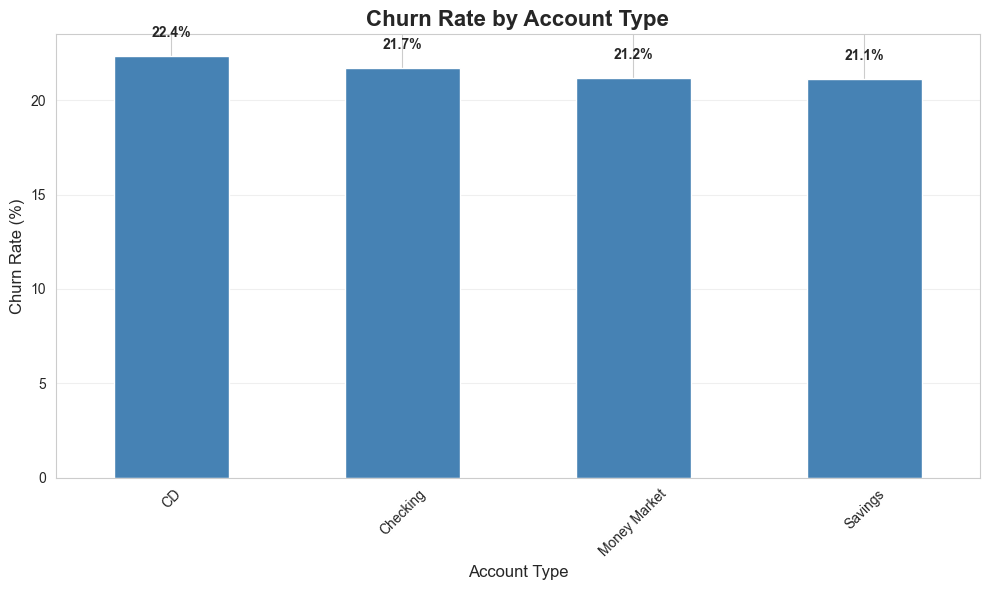


Churn Rate by Account Type:
              count  sum  churn_rate
account_type                        
CD             1265  283       22.37
Checking       1293  281       21.73
Money Market   1212  257       21.20
Savings        1230  260       21.14


In [18]:
# Churn rate by account type
churn_by_account = churn_df.groupby('account_type')['churn_status'].agg(['sum', 'count', 'mean'])
churn_by_account['churn_rate'] = churn_by_account['mean'] * 100

plt.figure(figsize=(10, 6))
ax = churn_by_account['churn_rate'].sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Account Type', fontsize=16, fontweight='bold')
plt.xlabel('Account Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(churn_by_account['churn_rate'].sort_values(ascending=False)):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nChurn Rate by Account Type:")
print(churn_by_account[['count', 'sum', 'churn_rate']].round(2))

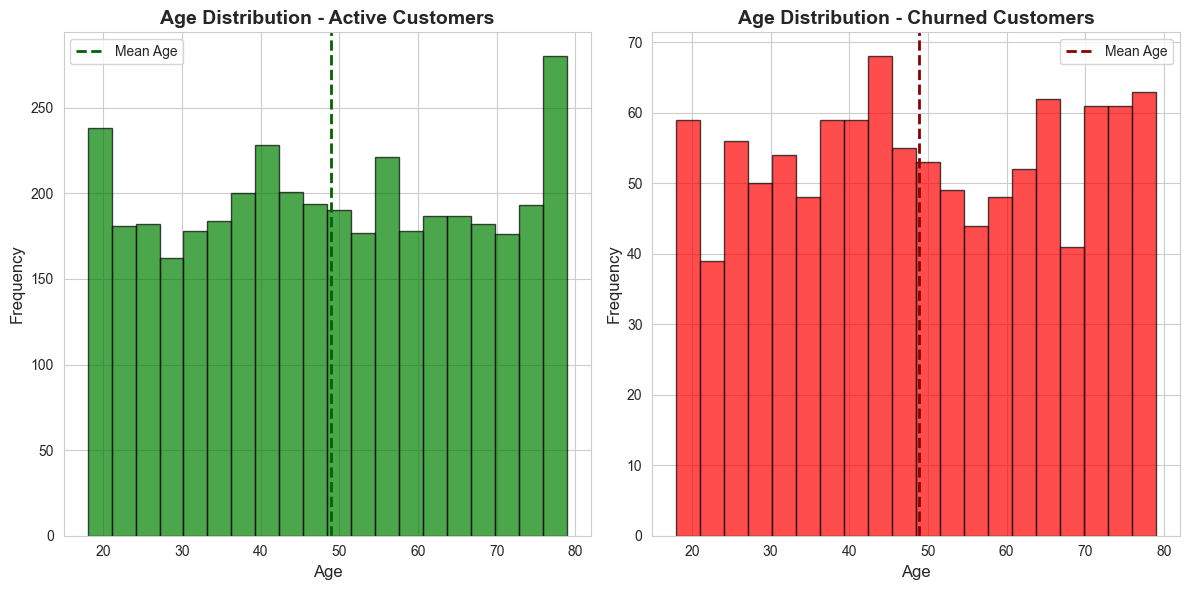


Age Statistics by Churn Status:
Active Customers - Mean Age: 48.9
Churned Customers - Mean Age: 48.9


In [19]:
# Age distribution by churn status
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
churn_df[churn_df['churn_status'] == 0]['age'].hist(bins=20, alpha=0.7, color='green', edgecolor='black')
plt.title('Age Distribution - Active Customers', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(churn_df[churn_df['churn_status'] == 0]['age'].mean(), 
            color='darkgreen', linestyle='--', linewidth=2, label='Mean Age')
plt.legend()

plt.subplot(1, 2, 2)
churn_df[churn_df['churn_status'] == 1]['age'].hist(bins=20, alpha=0.7, color='red', edgecolor='black')
plt.title('Age Distribution - Churned Customers', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(churn_df[churn_df['churn_status'] == 1]['age'].mean(), 
            color='darkred', linestyle='--', linewidth=2, label='Mean Age')
plt.legend()

plt.tight_layout()
plt.show()

print("\nAge Statistics by Churn Status:")
print("="*50)
print(f"Active Customers - Mean Age: {churn_df[churn_df['churn_status'] == 0]['age'].mean():.1f}")
print(f"Churned Customers - Mean Age: {churn_df[churn_df['churn_status'] == 1]['age'].mean():.1f}")

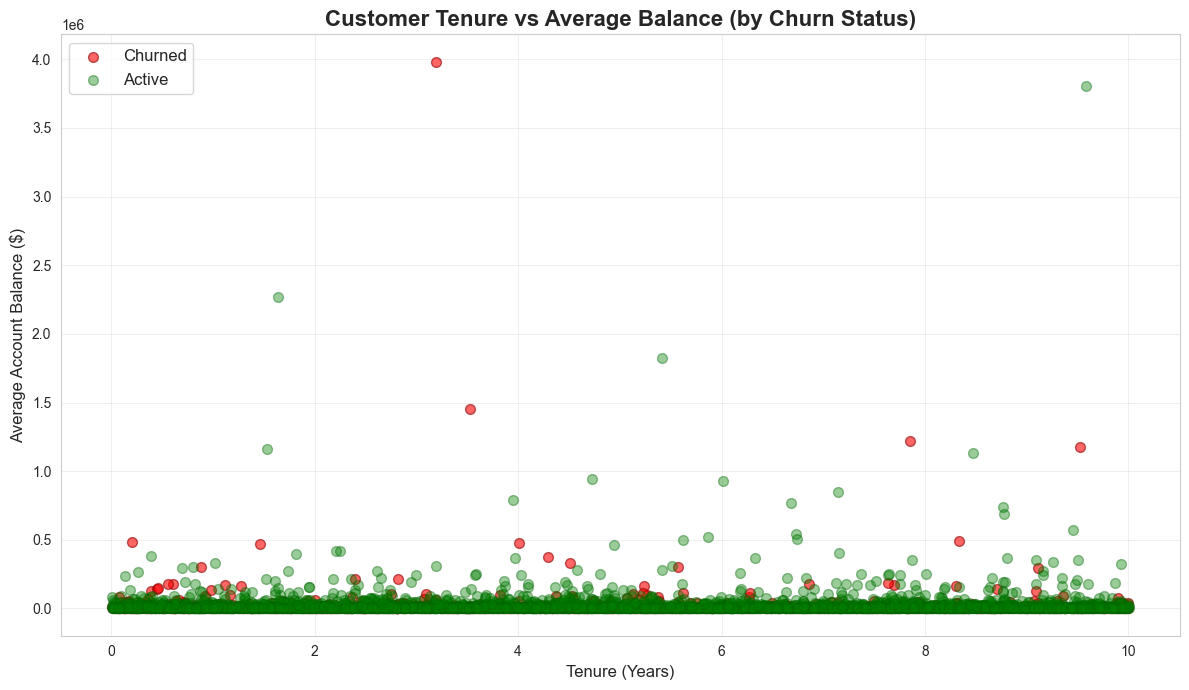


Balance and Tenure Statistics by Churn Status:

Active Customers:
  - Average Balance: $22,205.26
  - Average Tenure: 5.02 years

Churned Customers:
  - Average Balance: $22,264.68
  - Average Tenure: 4.52 years


In [20]:
# Scatter plot: Balance vs Tenure colored by churn status
plt.figure(figsize=(12, 7))

# Plot churned customers
churned = churn_df[churn_df['churn_status'] == 1]
plt.scatter(churned['tenure_years'], churned['balance'], 
           alpha=0.6, s=50, c='red', label='Churned', edgecolors='darkred')

# Plot active customers
active = churn_df[churn_df['churn_status'] == 0]
plt.scatter(active['tenure_years'], active['balance'], 
           alpha=0.4, s=50, c='green', label='Active', edgecolors='darkgreen')

plt.title('Customer Tenure vs Average Balance (by Churn Status)', fontsize=16, fontweight='bold')
plt.xlabel('Tenure (Years)', fontsize=12)
plt.ylabel('Average Account Balance ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBalance and Tenure Statistics by Churn Status:")
print("="*50)
print("\nActive Customers:")
print(f"  - Average Balance: ${active['balance'].mean():,.2f}")
print(f"  - Average Tenure: {active['tenure_years'].mean():.2f} years")
print("\nChurned Customers:")
print(f"  - Average Balance: ${churned['balance'].mean():,.2f}")
print(f"  - Average Tenure: {churned['tenure_years'].mean():.2f} years")

---
## Section 3: Loan Default Prediction Model

In this section, we build a machine learning model to predict loan defaults using logistic regression.

In [21]:
# Prepare data for modeling - filter only customers with loans
loan_df = df[df['loan_id'].notna()].copy()

# Aggregate at customer-loan level
loan_model_df = loan_df.groupby(['customer_id', 'loan_id']).agg({
    'age': 'first',
    'gender': 'first',
    'balance': 'mean',
    'tenure_days': 'first',
    'loan_amount': 'first',
    'interest_rate': 'first',
    'loan_term_months': 'first',
    'loan_status': 'first'
}).reset_index()

print(f"Total loans for modeling: {len(loan_model_df):,}")
print(f"\nLoan Status Distribution:")
print(loan_model_df['loan_status'].value_counts())
print(f"\nDefault Rate: {(loan_model_df['loan_status'] == 'Defaulted').mean() * 100:.2f}%")

Total loans for modeling: 2,000

Loan Status Distribution:
loan_status
Active       991
Paid Off     730
Defaulted    279
Name: count, dtype: int64

Default Rate: 13.95%


### Feature Engineering and Preprocessing

In [22]:
# Create binary target variable (1 = Defaulted, 0 = Not Defaulted)
loan_model_df['default'] = (loan_model_df['loan_status'] == 'Defaulted').astype(int)

# Create additional features
loan_model_df['loan_to_balance_ratio'] = loan_model_df['loan_amount'] / (loan_model_df['balance'] + 1)
loan_model_df['tenure_years'] = loan_model_df['tenure_days'] / 365.25

# Encode categorical variables
le_gender = LabelEncoder()
loan_model_df['gender_encoded'] = le_gender.fit_transform(loan_model_df['gender'])

# Select features for modeling
feature_columns = [
    'age', 
    'gender_encoded', 
    'balance', 
    'tenure_years',
    'loan_amount', 
    'interest_rate', 
    'loan_term_months',
    'loan_to_balance_ratio'
]

X = loan_model_df[feature_columns]
y = loan_model_df['default']

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)
print("\nFeatures used in model:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

Feature Matrix Shape: (2000, 8)
Target Variable Shape: (2000,)

Features used in model:
  1. age
  2. gender_encoded
  3. balance
  4. tenure_years
  5. loan_amount
  6. interest_rate
  7. loan_term_months
  8. loan_to_balance_ratio


In [23]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train):,}")
print(f"Testing set size: {len(X_test):,}")
print(f"\nTraining set default rate: {y_train.mean()*100:.2f}%")
print(f"Testing set default rate: {y_test.mean()*100:.2f}%")

Training set size: 1,600
Testing set size: 400

Training set default rate: 13.94%
Testing set default rate: 14.00%


In [24]:
# Train Logistic Regression model
print("Training Logistic Regression model...\n")
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
print("✓ Model trained successfully")

Training Logistic Regression model...

✓ Model trained successfully


In [25]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(f"\nTraining Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy: {test_accuracy*100:.2f}%")
print(f"\nModel Generalization: {'Good' if abs(train_accuracy - test_accuracy) < 0.05 else 'Check for overfitting'}")

MODEL PERFORMANCE

Training Accuracy: 85.94%
Testing Accuracy: 86.00%

Model Generalization: Good


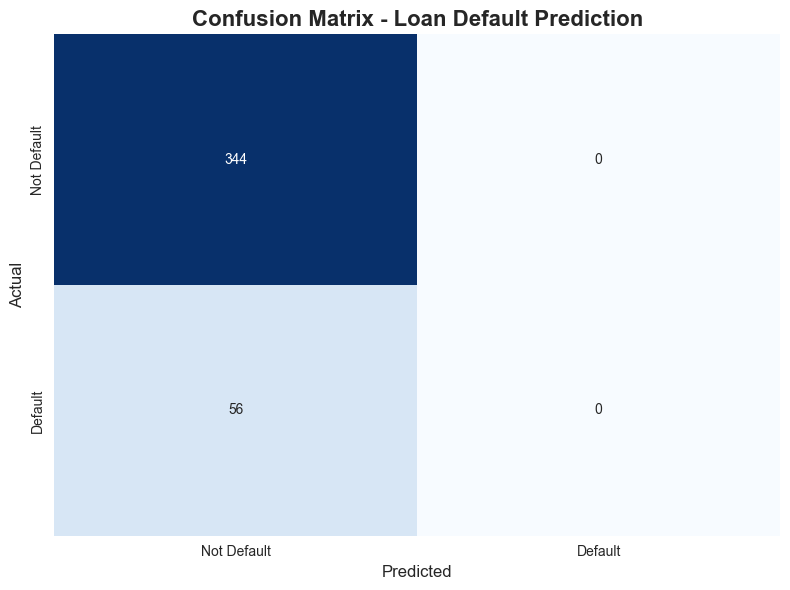


Confusion Matrix Breakdown:
  True Negatives: 344 (Correctly predicted non-defaults)
  False Positives: 0 (Incorrectly predicted as defaults)
  False Negatives: 56 (Missed defaults)
  True Positives: 0 (Correctly predicted defaults)


In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Default', 'Default'],
            yticklabels=['Not Default', 'Default'])
plt.title('Confusion Matrix - Loan Default Prediction', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives: {cm[0,0]} (Correctly predicted non-defaults)")
print(f"  False Positives: {cm[0,1]} (Incorrectly predicted as defaults)")
print(f"  False Negatives: {cm[1,0]} (Missed defaults)")
print(f"  True Positives: {cm[1,1]} (Correctly predicted defaults)")

In [27]:
# Detailed Classification Report
print("\nDetailed Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_test, target_names=['Not Default', 'Default']))


Detailed Classification Report:
              precision    recall  f1-score   support

 Not Default       0.86      1.00      0.92       344
     Default       0.00      0.00      0.00        56

    accuracy                           0.86       400
   macro avg       0.43      0.50      0.46       400
weighted avg       0.74      0.86      0.80       400



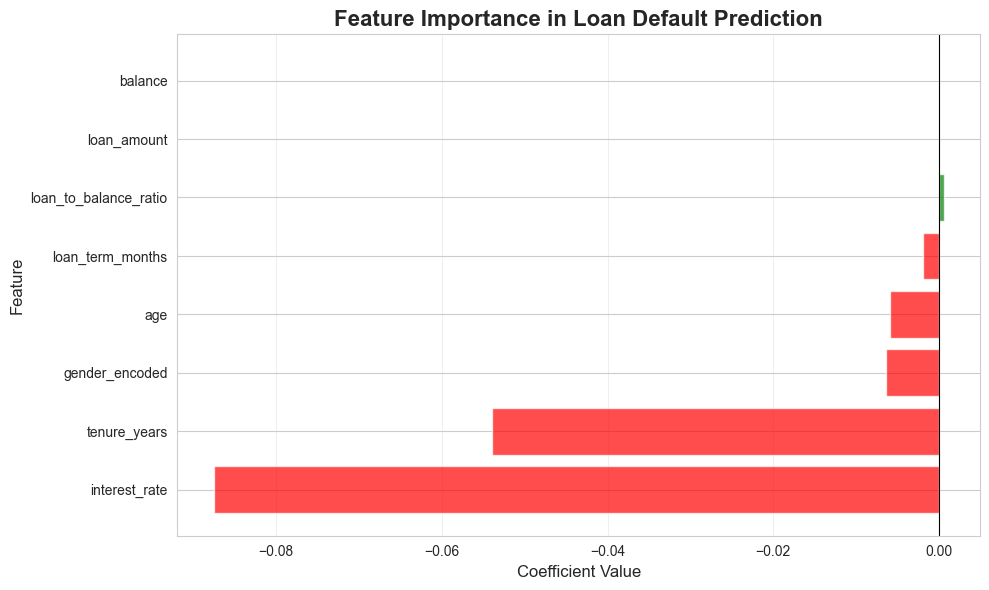


Feature Importance (Sorted by Absolute Coefficient):
              Feature  Coefficient
        interest_rate    -0.087523
         tenure_years    -0.053909
       gender_encoded    -0.006413
                  age    -0.005903
     loan_term_months    -0.001883
loan_to_balance_ratio     0.000544
          loan_amount    -0.000008
              balance    -0.000005


In [28]:
# Feature Importance (Coefficients)
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors, alpha=0.7)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Loan Default Prediction', fontsize=16, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFeature Importance (Sorted by Absolute Coefficient):")
print("="*60)
print(feature_importance.to_string(index=False))